# Reconstruction nosie for LiteBIRD
This code compute normalization and power spectrum of quadratic estiamtors with varying CMB noise level

In [2]:
# external
import numpy as np
from matplotlib.pyplot import *
# from cmblensplus/
from cmblensplus import basic, curvedsky as cs
# from cmblensplus/utils/
import plottools as pl
import cmb

Define functions

In [40]:
def compute_coadd_nl(sigmas,thetas,rlmax,Tcmb,ac2rad):
    nl = np.zeros((4,rlmax+1))
    for i, (sig, theta) in enumerate(zip(sigmas,thetas)):
        Nl = np.zeros((4,rlmax+1))
        Nl[0,:] = .5*(sig*ac2rad/Tcmb)**2*np.exp(L*(L+1.)*(theta*ac2rad)**2/np.log(2.)/8.)
        Nl[1,:] = 2.*Nl[0,:]
        Nl[2,:] = 2.*Nl[0,:]
        nl[0] += 1./Nl[0]
        nl[1] += 1./Nl[1]
        nl[2] += 1./Nl[2]
    nl[0] = 1./nl[0]
    nl[1] = 1./nl[1]
    nl[2] = 1./nl[2]
    return nl

First define parameters

In [13]:
Tcmb  = 2.726e6    # CMB temperature
Lmin, Lmax  = 2, 3000       # maximum multipole of output normalization
rlmin, rlmax = 2, 3000  # CMB multipole range for reconstruction
L = np.linspace(0,Lmax,Lmax+1)
Lfac = (L*(L+1.))**2/(2*np.pi)
ac2rad = np.pi/10800.
lTmax = rlmax
quad = ['TT','TE','EE','TB','EB','MV']
QDO = [True,True,True,True,True,False] # this means that TT, TE, EE, TB and EB are used for MV estimator

Load arrays of CMB unlensed and lensed Cls. Unlensed Cls are not used for now. The Cls should not be multiplied by any factors and should not have units.  

In [14]:
# ucl is an array of shape [0:5,0:rlmax+1] and ucl[0,:] = TT, ucl[1,:] = EE, ucl[2,:] = TE, lcl[3,:] = phiphi, lcl[4,:] = Tphi
ucl = cmb.read_camb_cls('../data/unlensedcls.dat',ftype='scal',output='array')[:,:rlmax+1] # TT, EE, TE, pp, Tp
# lcl is an array of shape [0:4,0:rlmax+1] and lcl[0,:] = TT, lcl[1,:] = EE, lcl[2,:] = BB, and lcl[3,:] = TE
lcl = cmb.read_camb_cls('../data/lensedcls.dat',ftype='lens',output='array')[:,:rlmax+1] # TT, EE, BB, TE

In [33]:
ckk = ucl[3]*(L*(L+1)/2.)**2

In [36]:
freqs1  = [ 40.0, 61.0, 50.0, 77.0,94.0,145.0,118.0,182.0,217.0,334.0,280.0,402.0]
thetas1 = [ 53.4, 37.8, 42.5, 29.9,22.6, 15.6, 18.5, 13.1, 10.3,  7.6,  8.0,  6.3]
sigmas1 = [35.96,18.90,20.61,10.51,7.20, 4.41, 4.71, 3.40, 8.59,14.93,11.27,33.62]

In [37]:
freqs0  = ['40', '50', '60', '68', '78', '89','100', '119','140','166','195','235','280','337','402']
sigmas0 = np.array([37.42,33.46,21.31,16.87,12.07,11.30,6.56,4.58,4.79,5.57,5.85,10.79,13.80,21.95,47.45])
thetas0 = np.array([70.5,58.5,51.1,45,40,37,34,30,27,28.9,28.6,24.7,22.5,20.9,17.9])

In [41]:
nl0 = compute_coadd_nl(sigmas0,thetas0,rlmax,Tcmb,ac2rad)
nl1 = compute_coadd_nl(sigmas1,thetas1,rlmax,Tcmb,ac2rad)

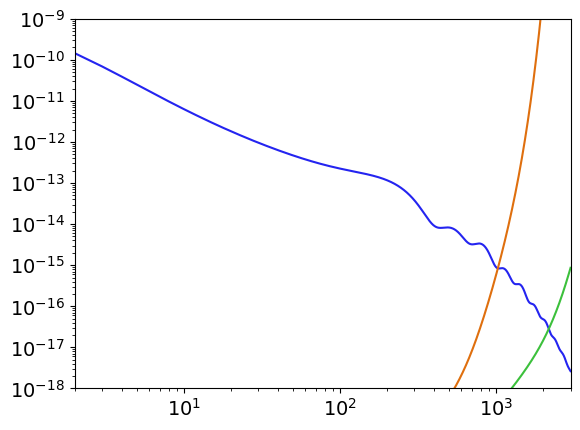

In [61]:
xlim(2,Lmax)
ylim(1e-18,1e-9)
#fac = L*(L+1)/2/np.pi * Tcmb**2
fac = 1
loglog(L,fac*lcl[0])
loglog(L,fac*nl0[0])
loglog(L,fac*nl1[0])

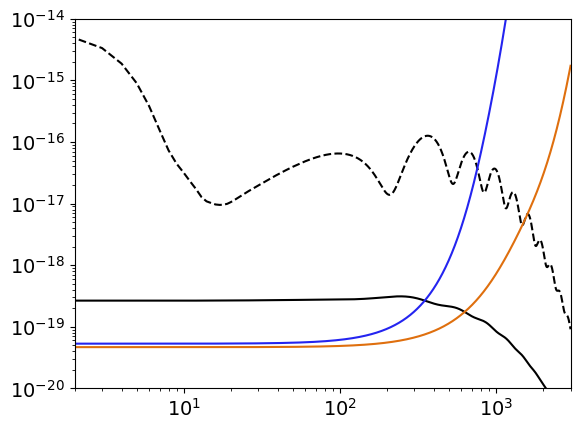

In [56]:
xlim(2,Lmax)
ylim(1e-20,1e-14)
fac = 1
loglog(fac*lcl[1],label='EE',color='k',ls='--')
loglog(fac*lcl[2],label='BB',color='k')
loglog(fac*nl0[1])
loglog(fac*nl1[1])

Loop over SNR calculation

In [62]:
Ag0, Ac0, __, __ = cs.norm_quad.qall('lens',QDO,Lmax,rlmin,rlmax,lcl,ocl+nl0,lfac='k')
Ag1, Ac1, __, __ = cs.norm_quad.qall('lens',QDO,Lmax,rlmin,rlmax,lcl,ocl+nl1,lfac='k')

 norm qTTTE
 norm qTTEE
 norm qTEEE
 norm qTBEB
 norm qMV
 norm qMV
 norm qTTTE
 norm qTTEE
 norm qTEEE
 norm qTBEB
 norm qMV
 norm qMV


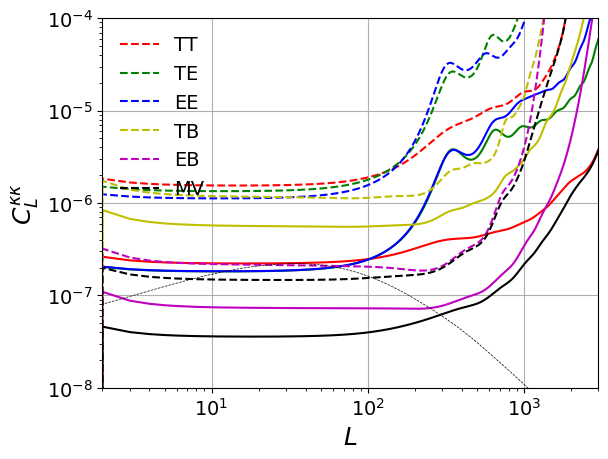

In [66]:
pl.plot_1dstyle(xmin=2,xmax=Lmax,ymin=1e-8,ymax=1e-4,xlab=r'$L$',ylab=r'$C^{\kappa\kappa}_L$',xlog=True,ylog=True,grid=True)
for qi, (c, q) in enumerate([('r','TT'),('g','TE'),('b','EE'),('y','TB'),('m','EB'),('k','MV')]):
    plot(L,Ag0[qi,:],color=c,ls='--',label=q)
    plot(L,Ag1[qi,:],color=c,ls='-')
plot(L,ckk,color='k',ls='--',lw=0.5)
legend()

In [68]:
fsky = 0.8
snr = np.zeros((2,6))
for qi in range(6):
    var_lm0 = ( ckk[Lmin:Lmax+1] + Ag0[qi,Lmin:Lmax+1] ) 
    var_lm1 = ( ckk[Lmin:Lmax+1] + Ag1[qi,Lmin:Lmax+1] ) 
    snr[0,qi] = np.sqrt( fsky*np.sum( (L[Lmin:Lmax+1]+.5) * ckk[Lmin:Lmax+1]**2/var_lm0**2 ) )
    snr[1,qi] = np.sqrt( fsky*np.sum( (L[Lmin:Lmax+1]+.5) * ckk[Lmin:Lmax+1]**2/var_lm1**2 ) )
print(snr)

[[  8.94959762   8.97715754  10.04431861  16.31851156  74.41141428
   81.44060674]
 [ 58.84355178  42.47998463  42.30483832  32.06263244 147.17223488
  172.48556339]]
